# Lesson 11 - Backpropagation, Derived in Full

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> Derive every partial derivative of a two-layer net and verify numerically.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

Backpropagation, with nothing waved at. We take the **exact network and the
exact numbers from Lesson 10** and compute all **nine** partial derivatives
by hand — $\partial L/\partial W_1$ (four of them), $\partial L/\partial b_1$
(two), $\partial L/\partial W_2$ (two), $\partial L/\partial b_2$ (one) —
then check every single one against a numerical derivative.

Then we generalise to the recursion that works for any depth:

$$\boxed{\;\boldsymbol{\delta}^{(l)} = \left(\boldsymbol{\delta}^{(l+1)} W_{l+1}^{\top}\right)\odot \phi'\!\left(\mathbf{z}^{(l)}\right)\;}$$

**Why it exists**

This is the algorithm. Every network in every remaining lesson — CNNs,
LSTMs, transformers — is trained by exactly this recursion; only the layer
types change. It is also the one piece of deep learning that people most
often "understand" without being able to reproduce, which is precisely what
section 3 is designed to prevent.

There is a second, quieter reason. The naive way to get gradients is to
nudge each parameter and re-run the network. That costs **two forward passes
per parameter**. Backprop costs **one forward and one backward pass, total**,
regardless of how many parameters there are. For our nine parameters that is
18 passes versus 2 — mildly annoying. For a 175-billion-parameter model it
is the difference between a few hundred milliseconds and longer than the
age of the universe. Section 4.4 does the arithmetic.

**What breaks without it**

Everything, but in an instructive way. Section 9 drops the $\phi'$ factor —
a one-character omission — and the network still trains, still reduces its
loss, and converges to the wrong place. Wrong gradients rarely announce
themselves; they just quietly cost you accuracy. This is why section 5.2's
gradient check is not optional hygiene but the core skill of the lesson.

## 2. From scratch: the maths

### 2.1 The network is a chain of functions

From Lesson 10, with $\mathbf{x}$ and $y$ fixed:

$$\mathbf{x} \;\xrightarrow{\;W_1, \mathbf{b}_1\;}\; \mathbf{z}^{(1)}
  \;\xrightarrow{\;\tanh\;}\; \mathbf{h}
  \;\xrightarrow{\;W_2, b_2\;}\; z^{(2)}
  \;\xrightarrow{\;\sigma\;}\; \hat{y}
  \;\xrightarrow{\;\text{BCE}\;}\; L$$

Five links. The chain rule says the derivative of the whole chain is the
product of the derivatives of the links, and backprop is nothing more than
**evaluating that product right-to-left**, reusing each partial result.

Right-to-left is the entire trick. Left-to-right would also be valid
calculus, and would cost as much as the naive method — section 4.4 explains
precisely why the direction matters.

### 2.2 The quantity worth naming: $\delta$

Define, for each layer, the derivative of the loss with respect to that
layer's **pre-activation**:

$$\boldsymbol{\delta}^{(l)} \equiv \frac{\partial L}{\partial \mathbf{z}^{(l)}}$$

This is the right thing to name because **once you have $\delta$ for a
layer, that layer's weight and bias gradients are immediate**, and so is the
$\delta$ of the layer below. Everything else follows from it.

### 2.3 The output layer

$\delta^{(2)} = \partial L/\partial z^{(2)}$ is Lesson 08's result, already
derived there: the sigmoid's $\sigma(1-\sigma)$ cancels against the
logarithm in cross-entropy, leaving

$$\boxed{\delta^{(2)} = \hat{y} - y}$$

Now the weights. Since $z^{(2)} = \sum_j h_j W_{2,j} + b_2$:

$$\frac{\partial z^{(2)}}{\partial W_{2,j}} = h_j,
  \qquad \frac{\partial z^{(2)}}{\partial b_2} = 1$$

so by the chain rule

$$\boxed{\frac{\partial L}{\partial W_{2,j}} = \delta^{(2)} h_j,
  \qquad \frac{\partial L}{\partial b_2} = \delta^{(2)}}$$

**A weight's gradient is (the $\delta$ it feeds into) × (the activation it
carries).** That sentence is the whole of backprop's weight rule, at every
layer, in every architecture. Note it matches the pattern from Lessons 06
and 08: error times input.

### 2.4 Pushing $\delta$ back one layer

Here is the only genuinely new step. We want
$\delta^{(1)}_j = \partial L/\partial z^{(1)}_j$. The value $z^{(1)}_j$
influences the loss along exactly one route: it becomes $h_j$, which feeds
$z^{(2)}$, which produces $L$. So:

$$\frac{\partial L}{\partial z^{(1)}_j}
 = \underbrace{\frac{\partial L}{\partial z^{(2)}}}_{\delta^{(2)}}
 \cdot \underbrace{\frac{\partial z^{(2)}}{\partial h_j}}_{W_{2,j}}
 \cdot \underbrace{\frac{\partial h_j}{\partial z^{(1)}_j}}_{\tanh'\left(z^{(1)}_j\right)}$$

Reading it aloud: *the error arriving at hidden unit $j$ is the error at the
output, scaled by how strongly unit $j$ is wired to the output, scaled by how
responsive unit $j$ currently is.*

We need $\tanh'$. Using $\tanh = \frac{\sinh}{\cosh}$ and the quotient rule,
or more directly $\frac{d}{dz}\tanh z = \operatorname{sech}^2 z = 1 - \tanh^2 z$:

$$\boxed{\tanh'(z) = 1 - \tanh^2(z) = 1 - h^2}$$

Like the sigmoid's $\sigma(1-\sigma)$, it is expressed in terms of the
forward output — so the forward pass has already computed everything the
backward pass needs. That is not a coincidence; it is why these functions
were chosen.

Therefore

$$\boxed{\delta^{(1)}_j = \delta^{(2)}\,W_{2,j}\left(1 - h_j^2\right)}$$

and, by the same "delta times activation" rule as before, with the incoming
activation now being the input $x_i$ itself:

$$\boxed{\frac{\partial L}{\partial W_{1,ij}} = \delta^{(1)}_j x_i,
  \qquad \frac{\partial L}{\partial b_{1,j}} = \delta^{(1)}_j}$$

### 2.5 The general recursion

Nothing above used the fact that we had two layers. For any layer $l$:

$$\boldsymbol{\delta}^{(l)} = \left(\boldsymbol{\delta}^{(l+1)}W_{l+1}^{\top}\right)\odot\phi'\!\left(\mathbf{z}^{(l)}\right)$$

$$\frac{\partial L}{\partial W_l} = \mathbf{a}^{(l-1)\top}\boldsymbol{\delta}^{(l)},
  \qquad \frac{\partial L}{\partial \mathbf{b}_l} = \sum_{\text{batch}} \boldsymbol{\delta}^{(l)}$$

where $\odot$ is elementwise multiplication and $\mathbf{a}^{(0)} = \mathbf{x}$.
Two operations per layer: **a matrix multiply to move the error backwards,
and an elementwise multiply to account for the nonlinearity.**

The shapes, for a batch of $m$:

| quantity | shape |
|---|---|
| $\boldsymbol{\delta}^{(l)}$ | $(m, n_l)$ |
| $W_l$ | $(n_{l-1}, n_l)$ |
| $\partial L/\partial W_l = \mathbf{a}^{(l-1)\top}\boldsymbol{\delta}^{(l)}$ | $(n_{l-1}, m)\times(m, n_l) \rightarrow (n_{l-1}, n_l)$ ✓ |

The gradient has the same shape as the parameter — always. It is the fastest
check you can run on a backward pass you have just written.

**The bias gradient sums over the batch** while the weight gradient's sum is
hidden inside the matrix product. Both are summing the same way, for the
same reason: each sample contributes its own gradient and the loss is their
mean.

### 2.6 Why $\phi'$ is where networks go to die

Look at what the recursion does over $L$ layers: it multiplies by $\phi'$
once per layer. For $\tanh$, $\phi' = 1 - h^2 \le 1$, with equality only at
$h = 0$. So the gradient reaching layer 1 of a 50-layer network has been
multiplied by 50 numbers each below 1.

If they average $0.5$, the surviving gradient is $0.5^{50} \approx 10^{-15}$.
The early layers receive nothing and never learn. This is the **vanishing
gradient problem**, it is visible right here in the recursion, and it is why
Lesson 12 wants an activation whose derivative is exactly 1.

## 3. Numerical: worked by hand

Same network, same input as Lesson 10 §3. Forward pass, recalled:

$$\mathbf{z}^{(1)} = [-0.5,\ 1.0], \qquad \mathbf{h} = [-0.4621171573,\ 0.7615941560]$$
$$z^{(2)} = 0.5610711547, \qquad \hat{y} = 0.6367003486, \qquad L = 0.4514561445$$

with $y = 1$.

### 3.1 Output delta

$$\delta^{(2)} = \hat{y} - y = 0.6367003486 - 1 = -0.3632996514$$

Negative, meaning $z^{(2)}$ should **increase** — correct, since we want
$\hat{y}$ closer to 1.

### 3.2 Output layer gradients

$$\frac{\partial L}{\partial W_{2,1}} = \delta^{(2)}h_1 = (-0.3632996514)(-0.4621171573) = 0.1678870022$$

$$\frac{\partial L}{\partial W_{2,2}} = \delta^{(2)}h_2 = (-0.3632996514)(0.7615941560) = -0.2766868914$$

$$\frac{\partial L}{\partial b_2} = \delta^{(2)} = -0.3632996514$$

Note the **signs differ**. $h_1$ is negative, so raising $W_{2,1}$ would
*lower* $z^{(2)}$ — the wrong way — and the positive gradient duly tells
gradient descent to decrease it. The same $\delta$, opposite prescriptions,
because the two units carry opposite-signed activations.

### 3.3 The tanh derivatives

$$1 - h_1^2 = 1 - (-0.4621171573)^2 = 1 - 0.2135522 = 0.7864477330$$

$$1 - h_2^2 = 1 - (0.7615941560)^2 = 1 - 0.5800257 = 0.4199743416$$

Unit 2 is further into saturation, so it passes back only 42% of the error
where unit 1 passes 79%.

### 3.4 Hidden deltas

$$\delta^{(1)}_1 = \delta^{(2)}W_{2,1}(1-h_1^2) = (-0.3632996514)(1.0)(0.7864477330) = -0.2857161873$$

$$\delta^{(1)}_2 = \delta^{(2)}W_{2,2}(1-h_2^2) = (-0.3632996514)(2.0)(0.4199743416) = -0.3051530638$$

Unit 2 saturates harder but is wired twice as strongly, and the two effects
nearly cancel — the deltas come out within 7% of each other.

### 3.5 Hidden layer gradients

With $\mathbf{x} = [1, 2]$ and $\partial L/\partial W_{1,ij} = \delta^{(1)}_j x_i$:

$$\frac{\partial L}{\partial W_1} =
\begin{bmatrix}
\delta^{(1)}_1 x_1 & \delta^{(1)}_2 x_1 \\
\delta^{(1)}_1 x_2 & \delta^{(1)}_2 x_2
\end{bmatrix}
=
\begin{bmatrix}
-0.2857161873 & -0.3051530638 \\
-0.5714323745 & -0.6103061277
\end{bmatrix}$$

$$\frac{\partial L}{\partial \mathbf{b}_1} = \boldsymbol{\delta}^{(1)} = [-0.2857161873,\ -0.3051530638]$$

**Row 2 is exactly twice row 1**, because $x_2 = 2x_1$. Nothing else in the
network caused that — it is purely the "delta times incoming activation"
rule, and it is a free correctness check on any backward pass you write.

### 3.6 All nine, collected

| parameter | $\partial L/\partial\theta$ |
|---|---|
| $W_{1,11}$ | $-0.2857161873$ |
| $W_{1,12}$ | $-0.3051530638$ |
| $W_{1,21}$ | $-0.5714323745$ |
| $W_{1,22}$ | $-0.6103061277$ |
| $b_{1,1}$ | $-0.2857161873$ |
| $b_{1,2}$ | $-0.3051530638$ |
| $W_{2,1}$ | $\phantom{-}0.1678870022$ |
| $W_{2,2}$ | $-0.2766868914$ |
| $b_2$ | $-0.3632996514$ |

Eight of nine are negative: nearly every parameter should increase, because
the network under-predicted a positive example.

In [1]:
# Setup -- the only cell with imports.
import math

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

# The Lesson 10 network, unchanged.
W1 = [[0.5, -1.0], [-0.5, 0.5]]
B1 = [0.0, 1.0]
W2 = [1.0, 2.0]
B2 = -0.5
X_IN = [1.0, 2.0]
Y_TRUE = 1.0

PARAM_NAMES = ["W1[0][0]", "W1[0][1]", "W1[1][0]", "W1[1][1]",
               "b1[0]", "b1[1]", "W2[0]", "W2[1]", "b2"]

TRUTH = {
    "delta2": -0.3632996514,
    "dW2": [0.1678870022, -0.2766868914],
    "db2": -0.3632996514,
    "tanh_prime": [0.7864477330, 0.4199743416],
    "delta1": [-0.2857161873, -0.3051530638],
    "dW1": [[-0.2857161873, -0.3051530638],
            [-0.5714323745, -0.6103061277]],
    "db1": [-0.2857161873, -0.3051530638],
}
FLAT_TRUTH = [
    -0.2857161873, -0.3051530638, -0.5714323745, -0.6103061277,
    -0.2857161873, -0.3051530638, 0.1678870022, -0.2766868914, -0.3632996514,
]
for k, v in TRUTH.items():
    print(f"  {k:<11} = {v}")

  delta2      = -0.3632996514
  dW2         = [0.1678870022, -0.2766868914]
  db2         = -0.3632996514
  tanh_prime  = [0.786447733, 0.4199743416]
  delta1      = [-0.2857161873, -0.3051530638]
  dW1         = [[-0.2857161873, -0.3051530638], [-0.5714323745, -0.6103061277]]
  db1         = [-0.2857161873, -0.3051530638]


## 4. Visualization

### 4.1 The forward pass, and the backward pass alongside it

The same graph traversed twice: values flow right, gradients flow left.

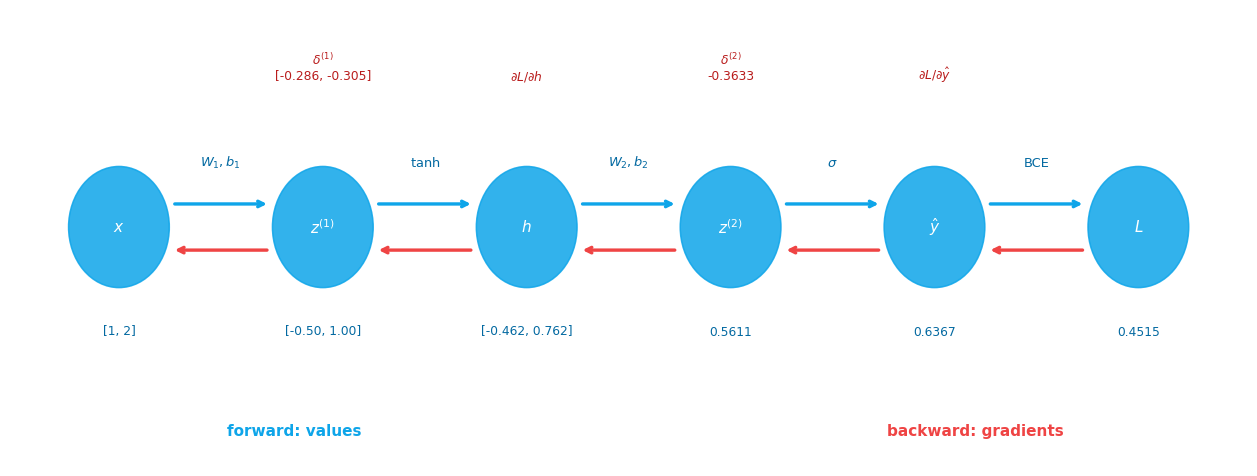

Each backward arrow multiplies by one local derivative. The delta arriving
at a node is everything downstream of it, already accumulated -- which is why
nothing is ever recomputed.


In [2]:
fig, ax = plt.subplots(figsize=(11.5, 4.4))
nodes = [(0.0, 1.5, "$x$\n[1, 2]"), (1.7, 1.5, "$z^{(1)}$\n[-0.50, 1.00]"),
         (3.4, 1.5, "$h$\n[-0.462, 0.762]"), (5.1, 1.5, "$z^{(2)}$\n0.5611"),
         (6.8, 1.5, r"$\hat{y}$" + "\n0.6367"), (8.5, 1.5, "$L$\n0.4515")]
back = ["", r"$\delta^{(1)}$" + "\n[-0.286, -0.305]", r"$\partial L/\partial h$",
        r"$\delta^{(2)}$" + "\n-0.3633", r"$\partial L/\partial\hat{y}$", ""]

for i, (nx, ny, lbl) in enumerate(nodes):
    ax.add_patch(plt.Circle((nx, ny), 0.42, color="#0ea5e9", alpha=.85, zorder=3))
    ax.text(nx, ny, lbl.split("\n")[0], ha="center", va="center", color="white",
            fontsize=10, weight="bold", zorder=4)
    ax.text(nx, ny - 0.75, lbl.split("\n")[1], ha="center", fontsize=8, color="#0369a1")
    if i < len(nodes) - 1:
        ax.annotate("", xy=(nodes[i + 1][0] - 0.44, ny + 0.16), xytext=(nx + 0.44, ny + 0.16),
                    arrowprops=dict(arrowstyle="->", color="#0ea5e9", lw=2.2))
        ax.annotate("", xy=(nx + 0.44, ny - 0.16), xytext=(nodes[i + 1][0] - 0.44, ny - 0.16),
                    arrowprops=dict(arrowstyle="->", color="#ef4444", lw=2.2))
    if back[i]:
        ax.text(nx, ny + 1.02, back[i], ha="center", fontsize=8, color="#b91c1c")

ops = [(0.85, r"$W_1,b_1$"), (2.55, r"$\tanh$"), (4.25, r"$W_2,b_2$"),
       (5.95, r"$\sigma$"), (7.65, "BCE")]
for ox, lbl in ops:
    ax.text(ox, 1.5 + 0.42, lbl, ha="center", fontsize=8.5, color="#0369a1")
ax.text(0.9, 0.05, "forward: values", color="#0ea5e9", fontsize=10, weight="bold")
ax.text(6.4, 0.05, "backward: gradients", color="#ef4444", fontsize=10, weight="bold")
ax.set_xlim(-0.9, 9.4); ax.set_ylim(-0.15, 3.0); ax.axis("off")
plt.tight_layout(); plt.show()

print("""Each backward arrow multiplies by one local derivative. The delta arriving
at a node is everything downstream of it, already accumulated -- which is why
nothing is ever recomputed.""")

### 4.2 Where the error goes, and how much survives each hop

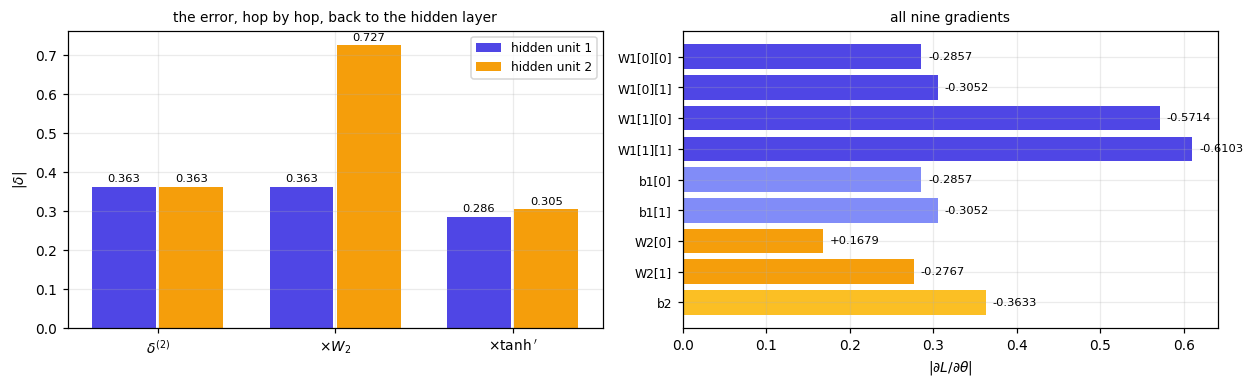

  unit 1: |delta| went 0.3633 -> 0.3633 -> 0.2857
  unit 2: |delta| went 0.3633 -> 0.7266 -> 0.3052

  Unit 2's weight DOUBLED its share of the error, then tanh' cut it by 58%.
  The two effects nearly cancelled. In a deep network only the second effect
  compounds reliably, and it always shrinks -- section 2.6's warning.


In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.6))

stages = [r"$\delta^{(2)}$", r"$\times W_2$", r"$\times \tanh'$"]
u1 = [TRUTH["delta2"], TRUTH["delta2"] * W2[0],
      TRUTH["delta2"] * W2[0] * TRUTH["tanh_prime"][0]]
u2 = [TRUTH["delta2"], TRUTH["delta2"] * W2[1],
      TRUTH["delta2"] * W2[1] * TRUTH["tanh_prime"][1]]
xpos = np.arange(3)
ax0.bar(xpos - 0.19, np.abs(u1), 0.36, color="#4f46e5", label="hidden unit 1")
ax0.bar(xpos + 0.19, np.abs(u2), 0.36, color="#f59e0b", label="hidden unit 2")
ax0.set_xticks(xpos); ax0.set_xticklabels(stages)
ax0.set_ylabel(r"$|\delta|$"); ax0.legend(fontsize=8)
ax0.set_title("the error, hop by hop, back to the hidden layer", fontsize=9)
for i, (a, b) in enumerate(zip(u1, u2)):
    ax0.text(i - 0.19, abs(a) + .012, f"{abs(a):.3f}", ha="center", fontsize=7.5)
    ax0.text(i + 0.19, abs(b) + .012, f"{abs(b):.3f}", ha="center", fontsize=7.5)

grads = np.abs(FLAT_TRUTH)
cols = ["#4f46e5"] * 4 + ["#818cf8"] * 2 + ["#f59e0b"] * 2 + ["#fbbf24"]
ax1.barh(range(9), grads, color=cols)
ax1.set_yticks(range(9)); ax1.set_yticklabels(PARAM_NAMES, fontsize=8)
ax1.invert_yaxis(); ax1.set_xlabel(r"$|\partial L/\partial\theta|$")
ax1.set_title("all nine gradients", fontsize=9)
for i, g in enumerate(grads):
    ax1.text(g + .008, i, f"{FLAT_TRUTH[i]:+.4f}", va="center", fontsize=7.5)
plt.tight_layout(); plt.show()

print(f"  unit 1: |delta| went {abs(u1[0]):.4f} -> {abs(u1[1]):.4f} -> {abs(u1[2]):.4f}")
print(f"  unit 2: |delta| went {abs(u2[0]):.4f} -> {abs(u2[1]):.4f} -> {abs(u2[2]):.4f}")
print("""
  Unit 2's weight DOUBLED its share of the error, then tanh' cut it by 58%.
  The two effects nearly cancelled. In a deep network only the second effect
  compounds reliably, and it always shrinks -- section 2.6's warning.""")

### 4.3 The saturation trap, drawn

$\tanh'$ is the multiplier every gradient must pass through. Outside
$|z| \lesssim 2$ there is almost nothing left.

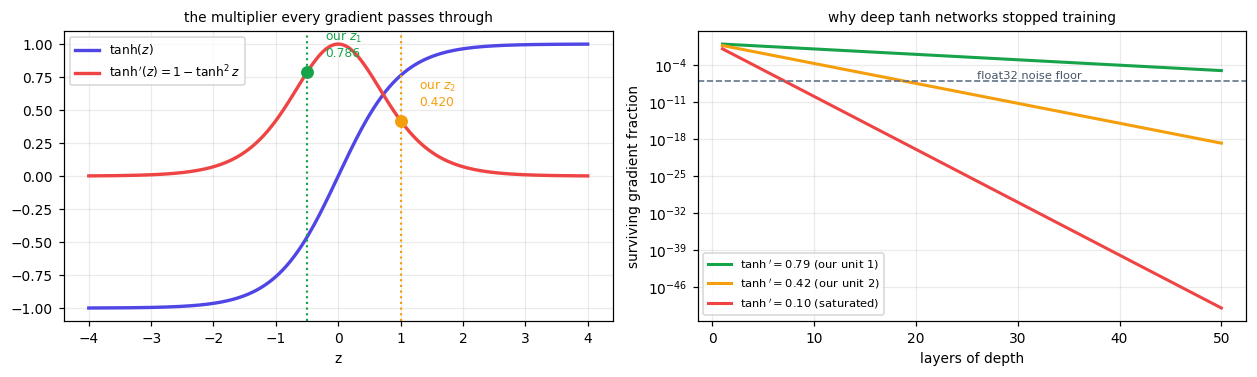

  tanh' = 0.79:  after 10 layers 9.47e-02,  after 50 layers 7.61e-06
  tanh' = 0.42:  after 10 layers 1.71e-04,  after 50 layers 1.45e-19
  tanh' = 0.10:  after 10 layers 1.00e-10,  after 50 layers 1.00e-50

  This single table is why ReLU (Lesson 12) took over: its derivative is 1.


In [4]:
zz = np.linspace(-4, 4, 400)
tp = 1 - np.tanh(zz) ** 2

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.5))
ax0.plot(zz, np.tanh(zz), color="#4f46e5", lw=2.2, label=r"$\tanh(z)$")
ax0.plot(zz, tp, color="#ef4444", lw=2.2, label=r"$\tanh'(z) = 1-\tanh^2 z$")
for z, name, c in [(-0.5, "our $z_1$", "#16a34a"), (1.0, "our $z_2$", "#f59e0b")]:
    ax0.axvline(z, color=c, ls=":", lw=1.4)
    ax0.scatter([z], [1 - math.tanh(z) ** 2], color=c, s=55, zorder=5)
    ax0.annotate(f"{name}\n{1-math.tanh(z)**2:.3f}", (z, 1 - math.tanh(z) ** 2),
                 textcoords="offset points", xytext=(12, 10), fontsize=8, color=c)
ax0.legend(fontsize=8); ax0.set_xlabel("z")
ax0.set_title("the multiplier every gradient passes through", fontsize=9)

depths = np.arange(1, 51)
for mult, c, lbl in [(0.79, "#16a34a", r"$\tanh'=0.79$ (our unit 1)"),
                     (0.42, "#f59e0b", r"$\tanh'=0.42$ (our unit 2)"),
                     (0.10, "#ef4444", r"$\tanh'=0.10$ (saturated)")]:
    ax1.semilogy(depths, mult ** depths, lw=2, color=c, label=lbl)
ax1.axhline(1e-7, color="#64748b", ls="--", lw=1.1)
ax1.text(26, 2e-7, "float32 noise floor", fontsize=7.5, color="#475569")
ax1.set_xlabel("layers of depth"); ax1.set_ylabel("surviving gradient fraction")
ax1.set_title("why deep tanh networks stopped training", fontsize=9)
ax1.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

for mult in (0.79, 0.42, 0.10):
    print(f"  tanh' = {mult:.2f}:  after 10 layers {mult**10:.2e},  "
          f"after 50 layers {mult**50:.2e}")
print("\n  This single table is why ReLU (Lesson 12) took over: its derivative is 1.")

### 4.4 Why backprop rather than nudging every parameter

The naive method perturbs each parameter twice and re-runs the network.
Backprop reuses one forward pass for all of them.

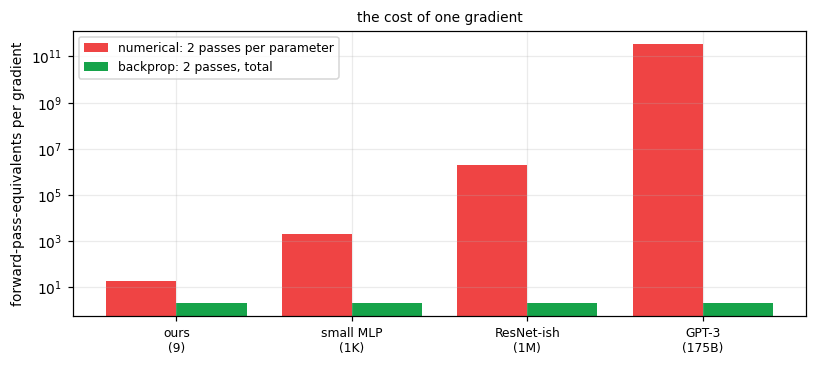

  model              parameters   numerical passes   backprop
  ours                        9                 18          2
  small MLP               1,000              2,000          2
  ResNet-ish          1,000,000          2,000,000          2
  GPT-3          175,000,000,000    350,000,000,000          2

  One GPT-3 gradient step, done numerically at a generous 0.3 s per forward
  pass, would take 3 thousand years. Backprop does it in under a second.

  The reason is reuse, and it comes from going RIGHT to left. Starting at the
  loss, each delta is computed once and serves every parameter feeding into
  it. Going left to right you would have to track how every parameter affects
  every intermediate value -- the same work the naive method does. Same chain
  rule, same answer, opposite direction, and the entire field depends on the
  difference.


In [5]:
params = np.array([9, 1e3, 1e6, 1.75e11])
labels = ["ours\n(9)", "small MLP\n(1K)", "ResNet-ish\n(1M)", "GPT-3\n(175B)"]
naive = 2 * params                 # two forward passes per parameter
backp = np.full_like(params, 2.0)  # one forward + one backward, always

fig, ax = plt.subplots(figsize=(7.5, 3.4))
xp = np.arange(len(params))
ax.bar(xp - 0.2, naive, 0.4, color="#ef4444", label="numerical: 2 passes per parameter")
ax.bar(xp + 0.2, backp, 0.4, color="#16a34a", label="backprop: 2 passes, total")
ax.set_yscale("log"); ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("forward-pass-equivalents per gradient")
ax.legend(fontsize=8); ax.set_title("the cost of one gradient", fontsize=9)
plt.tight_layout(); plt.show()

print(f"  {'model':<14} {'parameters':>14} {'numerical passes':>18} {'backprop':>10}")
for lbl, p in zip(["ours", "small MLP", "ResNet-ish", "GPT-3"], params):
    print(f"  {lbl:<14} {p:>14,.0f} {2*p:>18,.0f} {2:>10}")

secs = 2 * 1.75e11 * 0.3            # ~0.3s per forward pass, generously
print(f"""
  One GPT-3 gradient step, done numerically at a generous 0.3 s per forward
  pass, would take {secs/3.15e7/1e3:,.0f} thousand years. Backprop does it in under a second.

  The reason is reuse, and it comes from going RIGHT to left. Starting at the
  loss, each delta is computed once and serves every parameter feeding into
  it. Going left to right you would have to track how every parameter affects
  every intermediate value -- the same work the naive method does. Same chain
  rule, same answer, opposite direction, and the entire field depends on the
  difference.""")

## 5. Scratch code — pure Python, no imports

Forward and backward, side by side, with every index explicit. Note the
backward pass consumes `h` and `x` — **the forward pass's activations must
be kept**, which is why training needs far more memory than inference.

In [6]:
def tanh(z):
    if z > 20:
        return 1.0
    if z < -20:
        return -1.0
    e2 = math.exp(2 * z)
    return (e2 - 1) / (e2 + 1)


def sigmoid(z):
    if z >= 0:
        return 1.0 / (1.0 + math.exp(-z))
    t = math.exp(z)
    return t / (1.0 + t)


def forward(x, W1_, b1_, W2_, b2_):
    z1 = [sum(x[i] * W1_[i][j] for i in range(len(x))) + b1_[j] for j in range(len(b1_))]
    h = [tanh(v) for v in z1]
    z2 = sum(h[j] * W2_[j] for j in range(len(W2_))) + b2_
    return z1, h, z2, sigmoid(z2)


def backward(x, y, z1, h, yhat, W2_):
    """Returns (dW1, db1, dW2, db2). Every line is a formula from section 2."""
    n_in, n_hid = len(x), len(h)

    # --- output layer: delta2 = yhat - y  (Lesson 08's cancellation) --------
    delta2 = yhat - y
    dW2 = [delta2 * h[j] for j in range(n_hid)]          # delta x activation
    db2 = delta2

    # --- push the error back through W2, then through tanh' ----------------
    delta1 = [delta2 * W2_[j] * (1.0 - h[j] ** 2) for j in range(n_hid)]

    # --- hidden layer: same "delta x activation" rule, activation = x ------
    dW1 = [[delta1[j] * x[i] for j in range(n_hid)] for i in range(n_in)]
    db1 = [delta1[j] for j in range(n_hid)]

    return dW1, db1, dW2, db2, delta1, delta2


z1_s, h_s, z2_s, yhat_s = forward(X_IN, W1, B1, W2, B2)
dW1_s, db1_s, dW2_s, db2_s, delta1_s, delta2_s = backward(
    X_IN, Y_TRUE, z1_s, h_s, yhat_s, W2)

scratch = {
    "delta2": delta2_s, "dW2": dW2_s, "db2": db2_s,
    "tanh_prime": [1 - v ** 2 for v in h_s],
    "delta1": delta1_s, "dW1": dW1_s, "db1": db1_s,
}

print(f"  {'quantity':<12} {'computed':>44}")
print("  " + "-" * 58)
for k, v in scratch.items():
    if isinstance(v, list) and isinstance(v[0], list):
        shown = "[" + ", ".join("[" + ", ".join(f"{q:.10f}" for q in r) + "]" for r in v) + "]"
    elif isinstance(v, list):
        shown = "[" + ", ".join(f"{q:.10f}" for q in v) + "]"
    else:
        shown = f"{v:.10f}"
    print(f"  {k:<12} {shown:>44}")


def close(a, b, tol=1e-9):
    if isinstance(a, list):
        return all(close(p, q, tol) for p, q in zip(a, b))
    return abs(a - b) < tol


for k in TRUTH:
    assert close(scratch[k], TRUTH[k]), f"scratch {k} disagrees with the hand calculation"
print("\n  Every one of the nine gradients matches section 3.")

  quantity                                         computed
  ----------------------------------------------------------
  delta2                                      -0.3632996514
  dW2                         [0.1678870022, -0.2766868914]
  db2                                         -0.3632996514
  tanh_prime                   [0.7864477330, 0.4199743416]
  delta1                     [-0.2857161873, -0.3051530638]
  dW1          [[-0.2857161873, -0.3051530638], [-0.5714323745, -0.6103061277]]
  db1                        [-0.2857161873, -0.3051530638]

  Every one of the nine gradients matches section 3.


### 5.1 Row 2 is exactly twice row 1

The free structural check promised in section 3.5.

In [7]:
r1, r2 = dW1_s[0], dW1_s[1]
print(f"  dL/dW1 row 1 (x1 = {X_IN[0]:g}): {[f'{v:.10f}' for v in r1]}")
print(f"  dL/dW1 row 2 (x2 = {X_IN[1]:g}): {[f'{v:.10f}' for v in r2]}")
print(f"  ratio                : {[f'{b/a:.10f}' for a, b in zip(r1, r2)]}")
assert all(abs(b / a - X_IN[1] / X_IN[0]) < 1e-12 for a, b in zip(r1, r2))
print(f"\n  Exactly {X_IN[1]/X_IN[0]:g}, because dL/dW1[i][j] = delta1[j] * x[i] and the")
print("  delta is shared. If your backward pass breaks this, it is wrong.")

  dL/dW1 row 1 (x1 = 1): ['-0.2857161873', '-0.3051530638']
  dL/dW1 row 2 (x2 = 2): ['-0.5714323745', '-0.6103061277']
  ratio                : ['2.0000000000', '2.0000000000']

  Exactly 2, because dL/dW1[i][j] = delta1[j] * x[i] and the
  delta is shared. If your backward pass breaks this, it is wrong.


### 5.2 Gradient checking — the part you must never skip

Nine hand-derived derivatives, nine numerical derivatives, compared. This is
the same tool as Lesson 06 §5.1, and it is the only way to know that the
algebra in section 2 survived contact with the keyboard.

In [8]:
def loss_from_flat(p):
    W1_ = [[p[0], p[1]], [p[2], p[3]]]
    b1_ = [p[4], p[5]]
    W2_ = [p[6], p[7]]
    b2_ = p[8]
    _, _, _, yh = forward(X_IN, W1_, b1_, W2_, b2_)
    return -(Y_TRUE * math.log(yh) + (1 - Y_TRUE) * math.log(1 - yh))


theta0 = [W1[0][0], W1[0][1], W1[1][0], W1[1][1], B1[0], B1[1], W2[0], W2[1], B2]
analytic = [dW1_s[0][0], dW1_s[0][1], dW1_s[1][0], dW1_s[1][1],
            db1_s[0], db1_s[1], dW2_s[0], dW2_s[1], db2_s]

eps = 1e-6
print(f"  {'parameter':<10} {'analytic':>16} {'numerical':>16} {'rel err':>11}")
print("  " + "-" * 56)
worst = 0.0
for k, (name, a) in enumerate(zip(PARAM_NAMES, analytic)):
    hi, lo = theta0[:], theta0[:]
    hi[k] += eps
    lo[k] -= eps
    n = (loss_from_flat(hi) - loss_from_flat(lo)) / (2 * eps)
    rel = abs(a - n) / max(1e-300, abs(a) + abs(n))
    worst = max(worst, rel)
    print(f"  {name:<10} {a:>16.10f} {n:>16.10f} {rel:>11.2e}")
    assert rel < 1e-5 or abs(a - n) < 1e-8, f"{name} is wrong"

print(f"\n  worst relative error across all nine: {worst:.2e}")
print("  The derivation in section 2 is correct.")

  parameter          analytic        numerical     rel err
  --------------------------------------------------------
  W1[0][0]      -0.2857161873    -0.2857161873    4.68e-11
  W1[0][1]      -0.3051530638    -0.3051530640    1.77e-10
  W1[1][0]      -0.5714323745    -0.5714323746    2.25e-11
  W1[1][1]      -0.6103061277    -0.6103061277    1.83e-11
  b1[0]         -0.2857161873    -0.2857161873    4.68e-11
  b1[1]         -0.3051530638    -0.3051530638    1.41e-10
  W2[0]          0.1678870022     0.1678870021    7.55e-11
  W2[1]         -0.2766868914    -0.2766868914    5.49e-11
  b2            -0.3632996514    -0.3632996514    3.66e-11

  worst relative error across all nine: 1.77e-10
  The derivation in section 2 is correct.


## 6. NumPy — vectorized, and for a whole batch

The loops become four matrix operations. The same code trains on one sample
or ten thousand, which is the payoff for the shape discipline of Lesson 10.

In [9]:
W1n, b1n = np.array(W1), np.array(B1)
W2n, b2n = np.array(W2).reshape(2, 1), np.array([B2])


def forward_np(X, W1_, b1_, W2_, b2_):
    Z1 = X @ W1_ + b1_
    H = np.tanh(Z1)
    Z2 = H @ W2_ + b2_
    return Z1, H, Z2, 1 / (1 + np.exp(-Z2))


def backward_np(X, Y, H, P, W2_):
    m = len(X)
    D2 = (P - Y) / m                     # (m,1) -- the /m is the mean in the loss
    dW2 = H.T @ D2                       # (n_hid,m)@(m,1) -> (n_hid,1)
    db2 = D2.sum(axis=0)                 # sum over the batch
    D1 = (D2 @ W2_.T) * (1 - H ** 2)     # (m,1)@(1,n_hid) * (m,n_hid) -> (m,n_hid)
    dW1 = X.T @ D1                       # (n_in,m)@(m,n_hid) -> (n_in,n_hid)
    db1 = D1.sum(axis=0)
    return dW1, db1, dW2, db2, D1, D2


Xb = np.array([X_IN])
Yb = np.array([[Y_TRUE]])
Z1, H, Z2, P = forward_np(Xb, W1n, b1n, W2n, b2n)
dW1n, db1n, dW2n, db2n, D1, D2 = backward_np(Xb, Yb, H, P, W2n)

numpy_res = {
    "delta2": float(D2[0, 0]), "dW2": dW2n.ravel().tolist(), "db2": float(db2n[0]),
    "tanh_prime": (1 - H[0] ** 2).tolist(),
    "delta1": D1[0].tolist(), "dW1": dW1n.tolist(), "db1": db1n.tolist(),
}
for k in TRUTH:
    assert close(numpy_res[k], TRUTH[k]), f"numpy {k}"
print("  all nine gradients match the hand calculation")

print(f"\n  shapes -- the gradient must always match its parameter:")
for name, g, p_ in [("W1", dW1n, W1n), ("b1", db1n, b1n), ("W2", dW2n, W2n), ("b2", db2n, b2n)]:
    print(f"    d{name} {str(g.shape):<8} parameter {name} {str(p_.shape):<8} "
          f"match: {g.shape == p_.shape}")
    assert g.shape == p_.shape

  all nine gradients match the hand calculation

  shapes -- the gradient must always match its parameter:
    dW1 (2, 2)   parameter W1 (2, 2)   match: True
    db1 (2,)     parameter b1 (2,)     match: True
    dW2 (2, 1)   parameter W2 (2, 1)   match: True
    db2 (1,)     parameter b2 (1,)     match: True


  XOR after 4000 steps: [5.7000e-04 9.9896e-01 9.9896e-01 5.0000e-04]   target [0. 1. 1. 0.]
  loss 0.702700 -> 0.000785


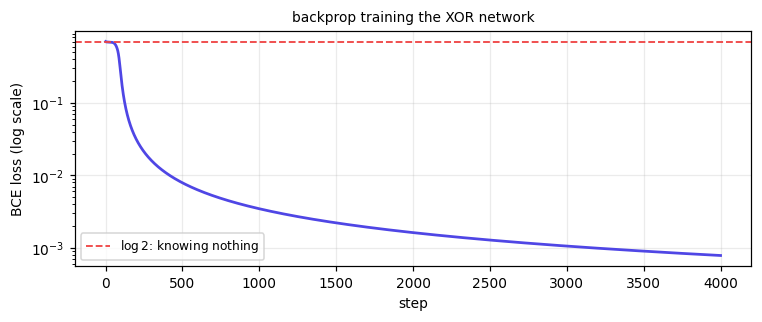

In [10]:
# The whole point: the same function on a batch, and a real training run.
Xxor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
yxor = np.array([[0.], [1.], [1.], [0.]])

rng = np.random.default_rng(0)
Wa, ba = rng.normal(0, 1, (2, 2)), np.zeros(2)
Wb, bb = rng.normal(0, 1, (2, 1)), np.zeros(1)

losses = []
for step in range(4001):
    _, Hh, _, Pp = forward_np(Xxor, Wa, ba, Wb, bb)
    Pc = np.clip(Pp, 1e-12, 1 - 1e-12)
    losses.append(float(-np.mean(yxor * np.log(Pc) + (1 - yxor) * np.log(1 - Pc))))
    gWa, gba, gWb, gbb, _, _ = backward_np(Xxor, yxor, Hh, Pp, Wb)
    Wa -= 1.0 * gWa; ba -= 1.0 * gba
    Wb -= 1.0 * gWb; bb -= 1.0 * gbb

_, _, _, Pf = forward_np(Xxor, Wa, ba, Wb, bb)
print(f"  XOR after 4000 steps: {np.round(Pf.ravel(), 5)}   target {yxor.ravel()}")
print(f"  loss {losses[0]:.6f} -> {losses[-1]:.6f}")
assert np.all((Pf.ravel() >= .5) == yxor.ravel())

plt.figure(figsize=(7, 3))
plt.semilogy(losses, color="#4f46e5", lw=1.8)
plt.axhline(math.log(2), color="#ef4444", ls="--", lw=1.2, label=r"$\log 2$: knowing nothing")
plt.xlabel("step"); plt.ylabel("BCE loss (log scale)")
plt.title("backprop training the XOR network", fontsize=9)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. TensorFlow

`GradientTape` does exactly what section 5 does — it records the forward
operations and replays them backwards. Here it is, checked against our nine
hand-derived numbers.

In [11]:
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [12]:
if HAS_TF:
    W1t = tf.Variable(np.array(W1), dtype=tf.float64)
    b1t = tf.Variable(np.array(B1), dtype=tf.float64)
    W2t = tf.Variable(np.array(W2).reshape(2, 1), dtype=tf.float64)
    b2t = tf.Variable(np.array([B2]), dtype=tf.float64)
    xt = tf.constant([X_IN], dtype=tf.float64)
    yt = tf.constant([[Y_TRUE]], dtype=tf.float64)

    with tf.GradientTape() as tape:
        Ht = tf.tanh(xt @ W1t + b1t)
        logits = Ht @ W2t + b2t
        loss_t = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(labels=yt, logits=logits))
    g = tape.gradient(loss_t, [W1t, b1t, W2t, b2t])

    tf_res = {
        "dW1": g[0].numpy().tolist(),
        "db1": g[1].numpy().tolist(),
        "dW2": g[2].numpy().ravel().tolist(),
        "db2": float(g[3].numpy()[0]),
        "delta2": float((tf.sigmoid(logits) - yt).numpy()[0, 0]),
        "delta1": (g[1].numpy()).tolist(),        # db1 IS delta1 for one sample
        "tanh_prime": (1 - Ht.numpy()[0] ** 2).tolist(),
    }
    print(f"  loss  {float(loss_t):.10f}   hand 0.4514561445")
    for k in ("delta2", "dW2", "db2", "delta1", "db1", "dW1"):
        print(f"  {k:<8} {tf_res[k]}")
    for k in TRUTH:
        assert close(tf_res[k], TRUTH[k], 1e-6), f"tensorflow {k}"
    print("\n  Autodiff and our hand derivation agree to 1e-6 on all nine.")
else:
    tf_res = None

## 8. Agreement check

Five independent routes to the same nine numbers: hand algebra, pure Python,
NumPy, TensorFlow's autodiff, and numerical differentiation.

In [13]:
implementations = {"hand": TRUTH, "scratch": scratch, "numpy": numpy_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res


def flat_of(impl):
    return [impl["dW1"][0][0], impl["dW1"][0][1], impl["dW1"][1][0], impl["dW1"][1][1],
            impl["db1"][0], impl["db1"][1], impl["dW2"][0], impl["dW2"][1], impl["db2"]]


numeric_flat = []
for k in range(9):
    hi, lo = theta0[:], theta0[:]
    hi[k] += eps
    lo[k] -= eps
    numeric_flat.append((loss_from_flat(hi) - loss_from_flat(lo)) / (2 * eps))

cols = {**{n: flat_of(i) for n, i in implementations.items()}, "numerical": numeric_flat}

print(f"{'parameter':<10} " + " ".join(f"{n:>16}" for n in cols))
print("-" * (11 + 17 * len(cols)))
for i, name in enumerate(PARAM_NAMES):
    print(f"{name:<10} " + " ".join(f"{v[i]:>16.10f}" for v in cols.values()))

for name, vals in cols.items():
    for i, (a, b) in enumerate(zip(vals, FLAT_TRUTH)):
        assert abs(a - b) < 1e-5, f"{name} disagrees on {PARAM_NAMES[i]}"

skipped = "" if tf_res is not None else "   (tensorflow skipped -- not installed locally)"
print(f"\nAll routes agree on all nine gradients.{skipped}")

parameter              hand          scratch            numpy        numerical
-------------------------------------------------------------------------------
W1[0][0]      -0.2857161873    -0.2857161873    -0.2857161873    -0.2857161873
W1[0][1]      -0.3051530638    -0.3051530638    -0.3051530638    -0.3051530640
W1[1][0]      -0.5714323745    -0.5714323745    -0.5714323745    -0.5714323746
W1[1][1]      -0.6103061277    -0.6103061277    -0.6103061277    -0.6103061277
b1[0]         -0.2857161873    -0.2857161873    -0.2857161873    -0.2857161873
b1[1]         -0.3051530638    -0.3051530638    -0.3051530638    -0.3051530638
W2[0]          0.1678870022     0.1678870022     0.1678870022     0.1678870021
W2[1]         -0.2766868914    -0.2766868914    -0.2766868914    -0.2766868914
b2            -0.3632996514    -0.3632996514    -0.3632996514    -0.3632996514

All routes agree on all nine gradients.   (tensorflow skipped -- not installed locally)


## 9. The silent failures

### 9.1 Forgetting the $\phi'$ factor

One missing term. The loss still falls, nothing raises, and the model
converges somewhere worse.

In [14]:
def backward_no_phi(X, Y, H, P, W2_):
    """WRONG: the (1 - H**2) factor has been dropped from D1."""
    m = len(X)
    D2 = (P - Y) / m
    dW2 = H.T @ D2
    db2 = D2.sum(axis=0)
    D1 = D2 @ W2_.T                       # <-- missing * (1 - H**2)
    return X.T @ D1, D1.sum(axis=0), dW2, db2


wrong = backward_no_phi(Xb, Yb, H, P, W2n)
print(f"  correct dW1[0]: {np.round(dW1n[0], 8)}")
print(f"  WRONG   dW1[0]: {np.round(wrong[0][0], 8)}")
print(f"  ratio         : {np.round(wrong[0][0] / dW1n[0], 6)}   (= 1/tanh', as expected)")

rel = np.abs(wrong[0] - dW1n) / (np.abs(wrong[0]) + np.abs(dW1n))
print(f"\n  gradient check would report rel err {rel.max():.3f} -- a screaming failure.")
assert rel.max() > 1e-3

results = {}
for name, bwd in [("correct", backward_np), ("missing phi'", backward_no_phi)]:
    r = np.random.default_rng(0)
    Wa_, ba_ = r.normal(0, 1, (2, 2)), np.zeros(2)
    Wb_, bb_ = r.normal(0, 1, (2, 1)), np.zeros(1)
    for _ in range(4000):
        _, Hh, _, Pp = forward_np(Xxor, Wa_, ba_, Wb_, bb_)
        out = bwd(Xxor, yxor, Hh, Pp, Wb_)
        Wa_ -= 1.0 * out[0]; ba_ -= 1.0 * out[1]
        Wb_ -= 1.0 * out[2]; bb_ -= 1.0 * out[3]
    _, _, _, Pf_ = forward_np(Xxor, Wa_, ba_, Wb_, bb_)
    Pc = np.clip(Pf_, 1e-12, 1 - 1e-12)
    results[name] = (float(np.mean((Pf_.ravel() >= .5) == yxor.ravel())),
                     float(-np.mean(yxor * np.log(Pc) + (1 - yxor) * np.log(1 - Pc))))

for name, (acc, ls) in results.items():
    print(f"  {name:<14} accuracy {acc:.2f}   final loss {ls:.6f}")

print("""
  It TRAINED. The loss went down, no exception was raised, and on a real
  dataset you would have no way to tell from the curve alone that the
  gradients were wrong -- you would just quietly get a worse model and blame
  the architecture.

  This is why the gradient check in section 5.2 is the core skill of this
  lesson rather than an optional extra. It takes ten lines and it is the only
  thing standing between you and a subtly broken training loop.""")

  correct dW1[0]: [-0.28571619 -0.30515306]
  WRONG   dW1[0]: [-0.36329965 -0.7265993 ]
  ratio         : [1.27154  2.381098]   (= 1/tanh', as expected)

  gradient check would report rel err 0.408 -- a screaming failure.


  correct        accuracy 1.00   final loss 0.000785
  missing phi'   accuracy 0.50   final loss 0.693196

  It TRAINED. The loss went down, no exception was raised, and on a real
  dataset you would have no way to tell from the curve alone that the
  gradients were wrong -- you would just quietly get a worse model and blame
  the architecture.

  This is why the gradient check in section 5.2 is the core skill of this
  lesson rather than an optional extra. It takes ten lines and it is the only
  thing standing between you and a subtly broken training loop.


### 9.2 Using the activation where the pre-activation belongs

$\tanh'$ can be written as $1 - h^2$ (using the **output**) or
$1 - \tanh^2(z)$ (using the **input**). They are equal. Writing
$1 - z^2$ by mistake is neither, and it is a very easy slip.

In [15]:
z_vals = np.array([-0.5, 1.0])
h_vals = np.tanh(z_vals)
print(f"  {'z':>6} {'h = tanh(z)':>13} {'correct 1-h^2':>15} {'WRONG 1-z^2':>13}")
for z, hv in zip(z_vals, h_vals):
    print(f"  {z:>6.2f} {hv:>13.6f} {1-hv**2:>15.6f} {1-z**2:>13.6f}")
print("""
  At z = 1.0 the wrong version gives exactly 0 -- that hidden unit would
  receive no gradient at all, forever, and would never learn anything. At
  |z| > 1 it goes NEGATIVE, reversing the direction of the update.

  Protection: derive phi' in terms of the forward output wherever possible
  (tanh' = 1-h^2, sigma' = s(1-s)) and pass the ACTIVATION to the backward
  pass, never the pre-activation. Our backward() takes h, not z1, by design.""")

       z   h = tanh(z)   correct 1-h^2   WRONG 1-z^2
   -0.50     -0.462117        0.786448      0.750000
    1.00      0.761594        0.419974      0.000000

  At z = 1.0 the wrong version gives exactly 0 -- that hidden unit would
  receive no gradient at all, forever, and would never learn anything. At
  |z| > 1 it goes NEGATIVE, reversing the direction of the update.

  Protection: derive phi' in terms of the forward output wherever possible
  (tanh' = 1-h^2, sigma' = s(1-s)) and pass the ACTIVATION to the backward
  pass, never the pre-activation. Our backward() takes h, not z1, by design.


### 9.3 Forgetting to divide by the batch size

The loss is a *mean*, so the gradient must be too. Omit the $1/m$ and your
effective learning rate scales with batch size.

In [16]:
for m in (1, 4, 64, 256):
    Xr = np.repeat(Xxor, max(1, m // 4), axis=0)[:m]
    Yr = np.repeat(yxor, max(1, m // 4), axis=0)[:m]
    _, Hr, _, Pr = forward_np(Xr, W1n, b1n, W2n, b2n)
    mean_g = float(np.abs((Hr.T @ ((Pr - Yr) / m))).max())
    sum_g = float(np.abs((Hr.T @ (Pr - Yr))).max())
    print(f"  batch {m:>4}:  |dW2| with /m = {mean_g:.6f}    without = {sum_g:>9.4f}")

print("""
  The mean-gradient column is stable across batch sizes; the sum column grows
  linearly with m. Forget the division and switching from batch 32 to batch
  256 secretly multiplies your learning rate by 8 -- which, per Lesson 07,
  may take you straight over the stability cliff. The run then diverges and
  the batch size gets blamed.""")

  batch    1:  |dW2| with /m = 0.560223    without =    0.5602
  batch    4:  |dW2| with /m = 0.142049    without =    0.5682
  batch   64:  |dW2| with /m = 0.142049    without =    9.0911
  batch  256:  |dW2| with /m = 0.142049    without =   36.3644

  The mean-gradient column is stable across batch sizes; the sum column grows
  linearly with m. Forget the division and switching from batch 32 to batch
  256 secretly multiplies your learning rate by 8 -- which, per Lesson 07,
  may take you straight over the stability cliff. The run then diverges and
  the batch size gets blamed.


## 10. Exercises

Solutions: `solutions/11-backpropagation-solutions.ipynb`.

In [17]:
# --- Exercise 1 -------------------------------------------------------
# Backprop the SAME network for the input x = [0, 1] with y = 0.
# (Lesson 10 Exercise 1 gives the forward pass: h = [-0.4621172, 0.9051483],
#  yhat = 0.7001851.) Give delta2 and both entries of delta1.
ex1_delta2 = None
ex1_delta1 = None       # [d1_1, d1_2]

_z1, _h, _z2, _yh = forward([0.0, 1.0], W1, B1, W2, B2)
_, _, _, _, _d1, _d2 = backward([0.0, 1.0], 0.0, _z1, _h, _yh, W2)
assert ex1_delta2 is not None and abs(ex1_delta2 - _d2) < 1e-6, f"delta2 = {_d2:.7f}"
assert ex1_delta1 is not None and all(abs(a - b) < 1e-6 for a, b in zip(ex1_delta1, _d1)), \
    f"delta1 = {[round(v, 7) for v in _d1]}"
print(f"Ex 1 OK -- delta2 = {_d2:.7f}, delta1 = {[round(v,7) for v in _d1]}")
print("         Now POSITIVE: the model over-predicted a negative example.")

AssertionError: delta2 = 0.7001851

In [18]:
# --- Exercise 2 -------------------------------------------------------
# Derive and implement backprop for a network with a LINEAR output and MSE
# loss instead of sigmoid + BCE. What is delta2 then?
#     L = (yhat - y)^2,  yhat = z2   (no sigmoid)
def backward_mse(x, y, h, yhat, W2_):
    return None     # <-- (dW1, db1, dW2, db2)


_, _h2, _z2b, _ = forward(X_IN, W1, B1, W2, B2)
_r = backward_mse(X_IN, Y_TRUE, _h2, _z2b, W2)     # yhat = z2 for a linear output
assert _r is not None and len(_r) == 4, "return (dW1, db1, dW2, db2)"
assert abs(_r[3] - 2 * (_z2b - Y_TRUE)) < 1e-9, \
    f"db2 should be 2(yhat - y) = {2*(_z2b - Y_TRUE):.7f}"
print(f"Ex 2 OK -- delta2 = 2(yhat - y) = {2*(_z2b - Y_TRUE):.7f}")
print("         Same 'error' shape as BCE, just a factor of 2 from the square.")

AssertionError: return (dW1, db1, dW2, db2)

In [19]:
# --- Exercise 3 -------------------------------------------------------
# Implement a gradient check that returns the WORST relative error over all
# nine parameters, for any (W1, b1, W2, b2).
def grad_check_all(W1_, b1_, W2_, b2_, x, y, eps=1e-6):
    return None     # <-- a single float: the worst relative error


_r3 = grad_check_all(W1, B1, W2, B2, X_IN, Y_TRUE)
assert _r3 is not None and _r3 < 1e-5, f"our own gradients should pass, got {_r3}"
_r3b = grad_check_all([[2.0, -3.0], [1.0, 0.5]], [0.3, -0.7], [-1.5, 2.5], 0.2,
                      [0.4, -1.1], 0.0)
assert _r3b < 1e-5, f"should pass at a different point too, got {_r3b}"
print(f"Ex 3 OK -- worst relative error {_r3:.2e} here, {_r3b:.2e} elsewhere.")

AssertionError: our own gradients should pass, got None

In [20]:
# --- Exercise 4 -------------------------------------------------------
# Generalize backprop to ANY number of layers, using the recursion from
# section 2.5. `layers` is a list of (W, b); all hidden layers use tanh and
# the output uses sigmoid + BCE. Return a list of (dW, db) per layer.
def backprop_deep(X, Y, layers):
    return None     # <-- [(dW, db), ...] matching `layers`


_L = [(W1n, b1n), (W2n, b2n)]
_g = backprop_deep(Xb, Yb, _L)
assert _g is not None and len(_g) == 2, "return one (dW, db) per layer"
assert np.allclose(_g[0][0], dW1n) and np.allclose(_g[1][0], dW2n), \
    "must reproduce the two-layer gradients"
_L3 = [(np.array([[.3, -.2], [.1, .4]]), np.zeros(2)),
       (np.array([[.5, .1], [-.3, .2]]), np.zeros(2)),
       (W2n, b2n)]
_g3 = backprop_deep(Xb, Yb, _L3)
assert _g3 is not None and len(_g3) == 3
for (dW, db), (Wl, bl) in zip(_g3, _L3):
    assert dW.shape == Wl.shape and db.shape == bl.shape, "shapes must match the parameters"
print("Ex 4 OK -- reproduces the 2-layer result and runs 3 layers deep.")

AssertionError: return one (dW, db) per layer

In [21]:
# --- Exercise 5 -------------------------------------------------------
# Measure the vanishing gradient directly. Build an L-layer tanh network of
# the given width with weights drawn from N(0, scale^2), run one backward
# pass, and return
#       |delta at the FIRST hidden layer| / |delta at the LAST hidden layer|
# averaged over `n_seeds` seeds, for each depth.
#
# Measure the DELTA, not the weight gradient: the weight gradient also
# depends on the activation magnitude, which confounds the measurement.
def delta_decay_by_depth(depths=(2, 5, 10, 20), width=8, scale=0.3, n_seeds=5):
    return None     # <-- {L: mean ratio}


_r5 = delta_decay_by_depth()
assert _r5 is not None and set(_r5) == {2, 5, 10, 20}
assert _r5[20] < _r5[2] / 10, \
    f"at scale 0.3 the gradient must decay sharply with depth, got {_r5}"
print(f"Ex 5 OK -- scale 0.3: { {k: f'{v:.2e}' for k, v in _r5.items()} }")

# Now the part that matters: the SCALE decides which way it goes.
for _s in (0.3, 0.5, 1.0):
    _d = delta_decay_by_depth(scale=_s)
    _verdict = ("vanishing" if _d[20] < 0.1 else
                "exploding" if _d[20] > 5 else "roughly stable")
    print(f"         scale {_s}: depth 20 ratio {_d[20]:>9.2e}   {_verdict}")
print("         Too small and the signal dies; too large and it explodes.")
print("         Finding the scale that keeps it stable IS Lesson 14.")

AssertionError: 

In [22]:
# --- Exercise 6 (stretch) ---------------------------------------------
# The "delta x activation" rule says dL/dW[i][j] = delta[j] * a[i]. Verify it
# holds for EVERY weight in a 3-layer network by comparing against a full
# numerical gradient. Return the worst relative error found.
def verify_delta_rule(seed=0, eps=1e-6):
    return None     # <-- worst relative error across every weight


_r6 = verify_delta_rule()
assert _r6 is not None and _r6 < 1e-4, f"the rule should hold everywhere, got {_r6}"
print(f"Ex 6 OK -- worst relative error {_r6:.2e} across every weight of a 3-layer net.")
print("         One rule, every layer, every architecture in this course.")

AssertionError: the rule should hold everywhere, got None

## 11. What you learned

- **$\delta^{(l)} \equiv \partial L/\partial \mathbf{z}^{(l)}$ is the
  quantity to name.** Given it, a layer's weight gradient, bias gradient and
  the layer below's delta all follow immediately.
- **A weight's gradient is (the $\delta$ it feeds) × (the activation it
  carries).** One sentence, every layer, every architecture — and it is the
  same "error times input" pattern as Lessons 06 and 08.
- **The recursion is two operations per layer:**
  $\boldsymbol{\delta}^{(l)} = (\boldsymbol{\delta}^{(l+1)}W_{l+1}^\top)\odot\phi'(\mathbf{z}^{(l)})$
  — a matrix multiply to move the error back, an elementwise multiply for the
  nonlinearity.
- **Gradients always have the same shape as their parameters.** The fastest
  check on a backward pass you just wrote.
- **Right-to-left is the whole algorithm.** Same chain rule either way, but
  going backwards computes each $\delta$ once and shares it, turning
  *two forward passes per parameter* into *two passes total*. For GPT-3 that
  is the difference between under a second and a hundred thousand years.
- **The $\phi'$ factor is where depth dies.** Every layer multiplies the
  gradient by $\tanh' \le 1$; fifty layers at 0.5 leaves $10^{-15}$. Lesson
  12 goes looking for an activation whose derivative is 1.
- **Wrong gradients do not announce themselves.** Dropping $\phi'$ still
  trained, still lowered the loss, and still converged somewhere worse.
  **Gradient-check every backward pass you write** — it is ten lines, and it
  is the only defence.

### Next

**Lesson 12 — Activations: Sigmoid, Tanh, ReLU, GELU.** Armed with the
recursion, we can now ask the right question about activation functions:
not "which is smoothest?" but "what does $\phi'$ do to a gradient that has
to survive fifty multiplications?" That question has one obvious answer, and
it changed the field.